In [2]:
from sklearn.datasets import make_circles
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
X,y=make_circles(n_samples=500,factor=0.1,noise=0.35,random_state=42)

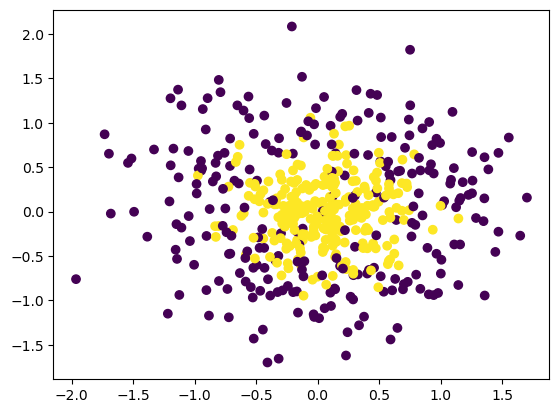

In [4]:
plt.scatter(X[:,0],X[:,1],c=y)

In [5]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [6]:
model=GradientBoostingClassifier()

In [7]:
model.fit(X,y)

GradientBoostingClassifier()

In [8]:
np.mean(cross_val_score(model,X,y,scoring='accuracy',cv=10))

0.82

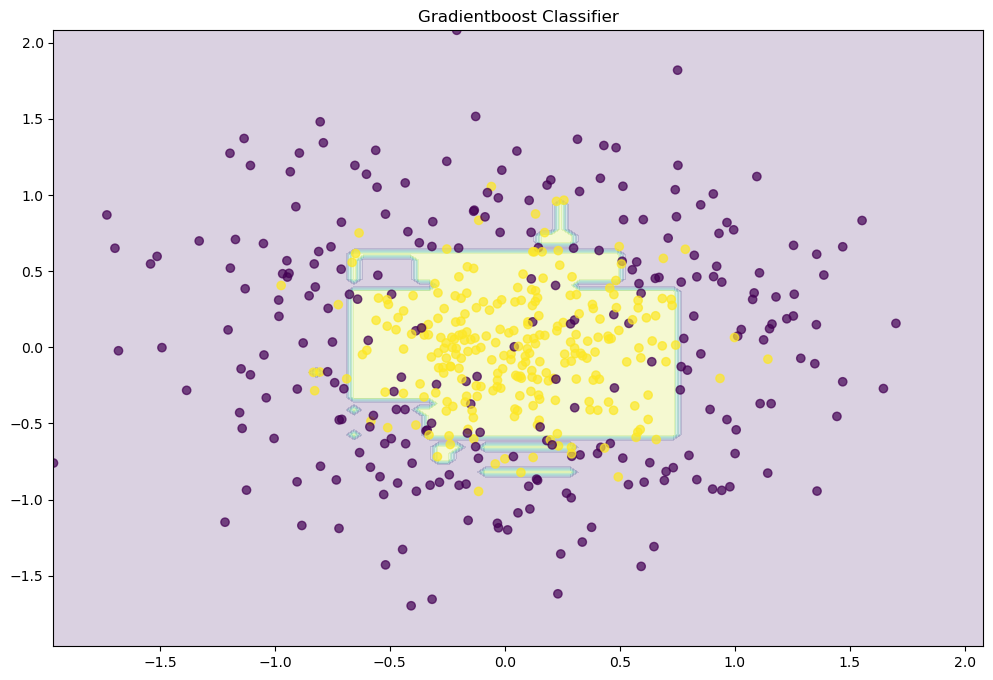

In [9]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12, 8))
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
    plt.title("Gradientboost Classifier")
    plt.show()
    
plot_decision_boundary(model)

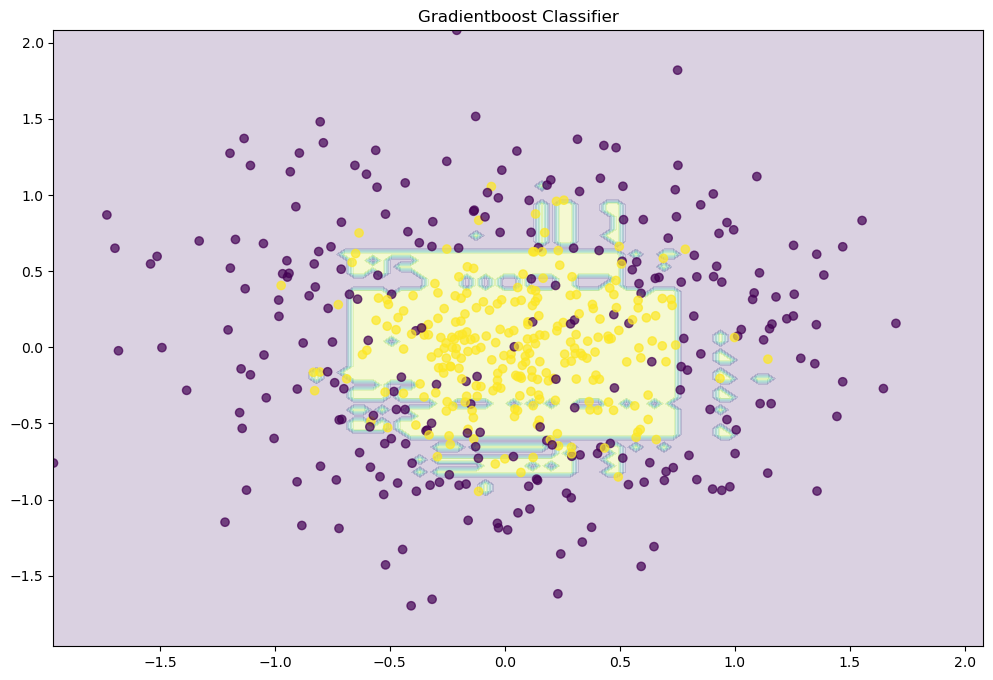

In [10]:
abc=GradientBoostingClassifier(n_estimators=1000)
abc.fit(X,y)
plot_decision_boundary(abc)

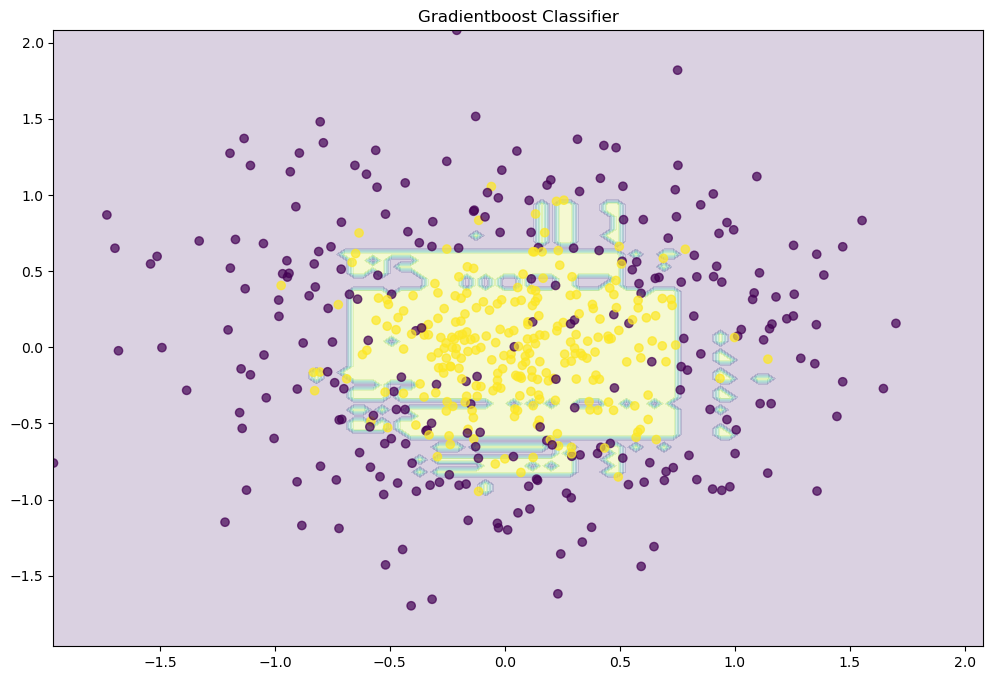

In [11]:
abc=GradientBoostingClassifier(n_estimators=1000,learning_rate=0.1)
abc.fit(X,y)
plot_decision_boundary(abc)

In [12]:
from sklearn.model_selection import GridSearchCV

In [13]:
parameters={
    'n_estimators':[10,150,500,1000],
    'learning_rate':[0.1,0.0001,0.001,0.01,1.0],
    'max_depth':[1,2,3,4,5],
    'loss':['log_loss', 'exponential'],
    'subsample':[0.1,0.01,0.001,0.0001]
}

In [14]:
grid_search=GridSearchCV(estimator=GradientBoostingClassifier(),param_grid=parameters,cv=10,scoring='accuracy',n_jobs=-1)

In [15]:
grid_search.fit(X,y)

GridSearchCV(cv=10, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.0001, 0.001, 0.01, 1.0],
                         'loss': ['log_loss', 'exponential'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'n_estimators': [10, 150, 500, 1000],
                         'subsample': [0.1, 0.01, 0.001, 0.0001]},
             scoring='accuracy')

In [16]:
print(grid_search.best_params_)

{'learning_rate': 0.0001, 'loss': 'exponential', 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.1}


In [17]:
print(grid_search.best_score_)

0.842


In [20]:
model=GradientBoostingClassifier(n_estimators=500,subsample=0.1,max_depth=4,learning_rate=0.0001,loss='exponential')

In [21]:
model.fit(X,y)

GradientBoostingClassifier(learning_rate=0.0001, loss='exponential',
                           max_depth=4, n_estimators=500, subsample=0.1)

In [23]:
np.mean(cross_val_score(model,X,y,scoring='accuracy',cv=10))

0.8300000000000001